In [171]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from pathlib import Path

In [284]:
# === SETTINGS ===
ID = "A1"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent/ "data"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Results directory 
results_dir = dir_path.parent / "results"
# Plots directory 
plots_dir = results_dir / "plots" 
# Results data directory 
results_data_dir = results_dir/ "data"
# SST data directory 
SST_data_dir = results_data_dir / "SST_SML_postprocessed"

# Halobates file
halobates_files = sorted(halobates_dir.glob(f"*{ID}_Halobates.csv"))
halobates_file  = str(halobates_files[0])

# Automatically find the latest (or 'only) file for the given station
SST_files = sorted(SST_data_dir.glob(f"SST_SML_1s_{ID}.csv"))
SST_file = SST_files[0]

# === Debug output (optional) ===
print("Data directory:", data_dir )
print("Averaged SST clean file:", SST_file)
print("Halobates data file:", halobates_file)

Current working directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/map_IR
Data directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/data
Averaged SST clean file: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/results/data/SST_SML_postprocessed/SST_SML_1s_A1.csv
Halobates data file: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/data/halobates_data/A1_Halobates.csv


In [285]:
# === Load water and sky data ===
df_SST = pd.read_csv(SST_file, sep=",", decimal=".")

# Remove white spaces from the columns titles
df_SST.columns = df_SST.columns.str.strip() 

# Update time format
df_SST['Time'] = pd.to_datetime(df_SST['Time'])

# === Load water and sky data ===
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Rename time column for consistency    
df_halo = df_halo.rename(columns={'Date_Time': 'Time'})

In [286]:
# === Check for duplicates ===

def check_duplicates(df, name):
    dups = df[df.duplicated(subset='Time', keep=False)]
    if dups.empty:
        print(f"No duplicate timestamps in {name}.")
    else:
        print(f"Found {len(dups)} duplicate rows in {name}.")
        print(dups.head())
    return dups

# === Drop rows with zero time difference and exact same temperature values === 

def drop_exact_duplicate_timestamps(df, name, value_column):
    df = df.sort_values('Time').reset_index(drop=True)
    df['dt'] = df['Time'].diff()

    # Find rows where the timestamp is duplicated (dt == 0)
    duplicates = df[df['dt'] == pd.Timedelta(0)]
    dropped_indices = []

    for idx in duplicates.index:
        curr_val = df.loc[idx, value_column]
        prev_val = df.loc[idx - 1, value_column]

        if curr_val == prev_val:
            dropped_indices.append(idx)
        else:
            print(f"Different values at duplicate timestamp (index {idx}): {prev_val} ≠ {curr_val}")

    df_cleaned = df.drop(index=dropped_indices).reset_index(drop=True)

    print(f"Dropped {len(dropped_indices)} exact duplicate rows from {name}.")

    return df_cleaned.drop(columns='dt')

dups_halo = check_duplicates(df_halo, "Halobates")
df_halo_overlap = drop_exact_duplicate_timestamps(df_halo, "Halobates", 'Time')

dups_SST = check_duplicates(df_SST, "SST")
df_SST_overlap = drop_exact_duplicate_timestamps(df_SST, "SST", 'Time')

No duplicate timestamps in Halobates.
Dropped 0 exact duplicate rows from Halobates.
No duplicate timestamps in SST.
Dropped 0 exact duplicate rows from SST.


In [287]:
def filter_overlapping_dates(df1, df2, sst_col="SST_filtered (°C)"):

    date_col1='Time'
    date_col2='Time'
    # Copy to avoid modifying original data
    df1 = df1.copy()
    df2 = df2.copy()

    # Convert time columns to datetime
    df1[date_col1] = pd.to_datetime(df1[date_col1])
    df2[date_col2] = pd.to_datetime(df2[date_col2])

    # Find the first and last non-NaN SST time in df2
    valid_sst_times = df2.loc[df2[sst_col].notna(), date_col2]

    if valid_sst_times.empty:
        raise ValueError("No non-NaN SST values found in df2.")

    start_time = valid_sst_times.min()
    end_time = valid_sst_times.max()

    # Filter df2 by the SST-valid time window
    df2 = df2[(df2[date_col2] >= start_time) & (df2[date_col2] <= end_time)]

    # Also filter df1 to the same time window to keep logical overlap
    df1 = df1[(df1[date_col1] >= start_time) & (df1[date_col1] <= end_time)]

    # Now find exact overlapping timestamps
    overlapping_times = set(df1[date_col1]) & set(df2[date_col2])

    # Final filtering by matching timestamps
    df1_filtered = df1[df1[date_col1].isin(overlapping_times)].sort_values(by=date_col1)
    df2_filtered = df2[df2[date_col2].isin(overlapping_times)].sort_values(by=date_col2)

    return df1_filtered, df2_filtered

In [288]:
# === Check halobates and IR cameras are clipped in the clean time window ===

df_halo_overlap, df_SST_overlap =filter_overlapping_dates(df_halo, df_SST, sst_col="SST_filtered (°C)")

# === Reset index after filtering ===
df_halo_overlap.reset_index(drop=True, inplace=True)
df_SST_overlap.reset_index(drop=True, inplace=True)

# === Compare lengths ===
len_halo = len(df_halo_overlap)
len_sst = len(df_SST_overlap)

print(f"Halobates rows: {len_halo}, SST rows: {len_sst}")

# === Compare time columns to check alignment ===
if len_halo == len_sst:
    time_diff = df_halo_overlap['Time'] - df_SST_overlap['Time']
    if all(time_diff == pd.Timedelta(0)):
        print("Timestamps are perfectly aligned.")
    else:
        print("Same length but timestamps do not match exactly.")
        print(time_diff.head())
else:
    print("Mismatch in number of data points after filtering.")

Halobates rows: 46849, SST rows: 46849
Timestamps are perfectly aligned.


In [289]:
# === Function to plot SST vs Halobates coordinates===

def map_SST(df_halo_overlap, df_SST_overlap, value_column, hour_gap):
    # Sample data
    lats = df_halo_overlap["Latitude"]
    lons = df_halo_overlap["Longitude"]
    temps = df_SST_overlap[value_column]  # °C
    times = pd.to_datetime(df_halo_overlap["Time"])

    # Set colorbar limits
    temp_min = temps.min()
    temp_max = temps.max()

    # Plotting
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, edgecolor='black')

    # Add lat/lon gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Scatter plot with temperature color scale
    sc = ax.scatter(
        lons, lats, c=temps,
        cmap='coolwarm', s=12,
        vmin=temp_min, vmax=temp_max,
        transform=ccrs.PlateCarree()
    )

    # Add trajectory line
    ax.plot(lons, lats, color='gray', linestyle='--', transform=ccrs.PlateCarree())

    # Label points each hour

    hourly_mask = times.dt.floor('H') != times.shift(1).dt.floor('H')

    lats_hourly = lats[hourly_mask]
    lons_hourly = lons[hourly_mask]
    times_hourly = times[hourly_mask]

    hours_plot = list(range(0, len(lats_hourly), hour_gap))

    lats_filtered = lats_hourly[lats_hourly.index[hours_plot]]
    lons_filtered = lons_hourly[lons_hourly.index[hours_plot]]
    times_filtered= times_hourly[times_hourly.index[hours_plot]]

    for lat, lon, time in zip(lats_filtered , lons_filtered , times_filtered ):
        ax.text(
            lon, lat, time.strftime('%H:%M'),
            fontsize=12, color='black',
            transform=ccrs.PlateCarree()
        )

    # Create colorbar same height as map
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1, axes_class=plt.Axes)

    cbar = plt.colorbar(sc, cax=cax, orientation='vertical')
    cbar.set_label("SST (°C)")

    # Title centered on map
    ax.set_title("SST Along Trajectory on station " + ID, fontsize=14, loc='center')

    plt.tight_layout()
    plt.savefig(plots_dir / "SST_maps" / f"SST_map_{ID}.png", dpi=600,  bbox_inches='tight')
    plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


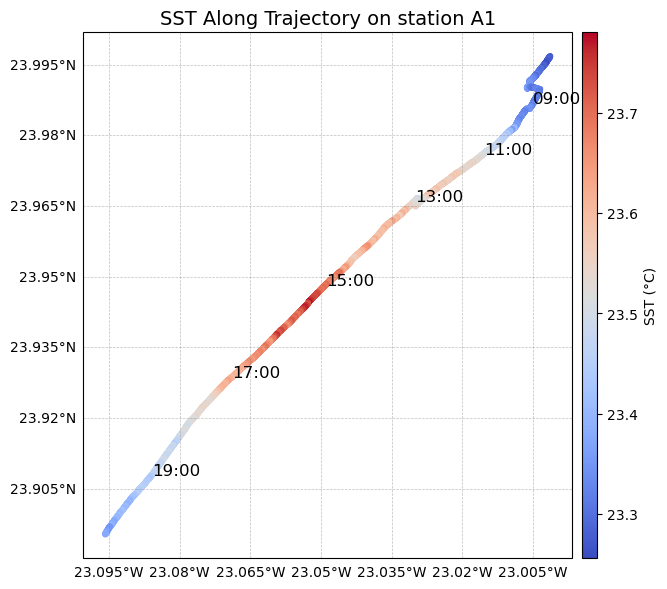

In [290]:
map_SST(df_halo_overlap, df_SST_overlap, "SML_filtered (°C)", 2)